# Neural Network Example

Xây dựng neural network với hai tầng ẩn (hidden layer). Các trọng số và mối liên hệ giữa các tầng ẩn được thiết lập và cài đặt bằng việc sử dụng API của thư viện PyTorch

## Neural Network Overview

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>

## MNIST Dataset Overview



In [1]:
import torch

In [2]:
print(torch.__version__)
print("CUDA available: ", torch.cuda.is_available())

2.8.0+cu126
CUDA available:  False


In [3]:
from __future__ import absolute_import, division, print_function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.autograd import Variable
import numpy as np

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
# Chuẩn bị dữ liệu
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [7]:
# Chuyển đổi sang định dạng float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Chuẩn hóa ảnh từ from [0, 255] to [0, 1].
x_train, x_test = x_train / 255, x_test / 255
x_train, x_test, y_train, y_test = torch.from_numpy(x_train), torch.from_numpy(x_test), torch.from_numpy(y_train).type(torch.LongTensor), torch.from_numpy(y_test).type(torch.LongTensor)

In [8]:
x_train

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [9]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
n_hidden_2 = 256 # 2nd layer number of neurons.

In [10]:
batch_size = 16

In [11]:
trainloader = []
for (i,j) in zip(x_train, y_train):
    trainloader.append([i,j])
trainloader = torch.utils.data.DataLoader(trainloader, shuffle=True, batch_size=batch_size)

testloader = []
for (i,j) in zip(x_test, y_test):
    testloader.append([i,j])
testloader = torch.utils.data.DataLoader(testloader, shuffle=True, batch_size=batch_size)

## Hiển thị một vài ví dụ

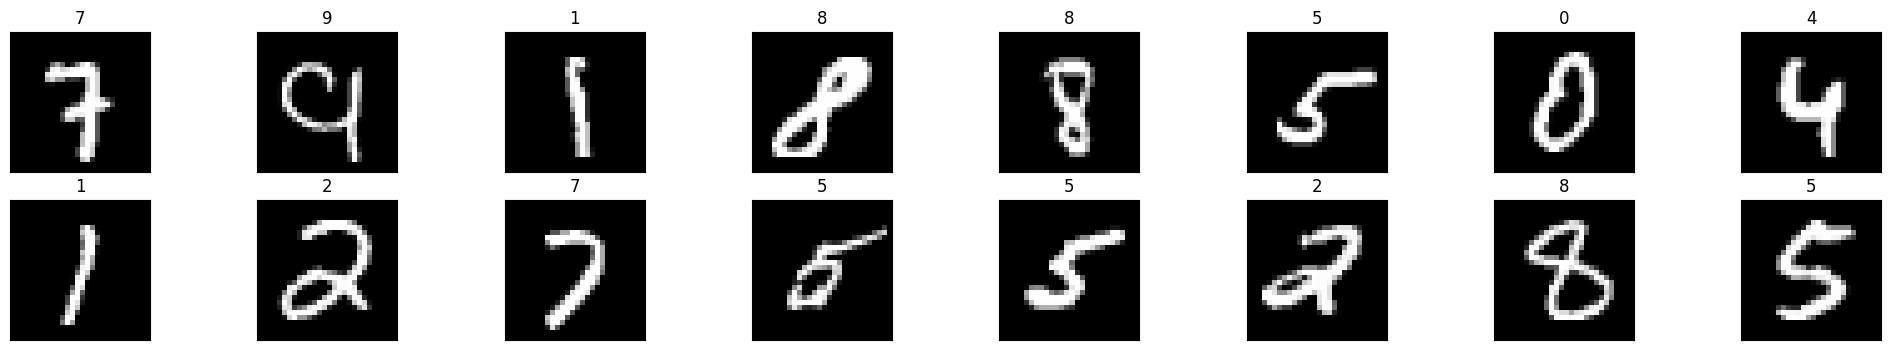

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

dataiter = iter(trainloader)
images, labels = next(dataiter)
images = images.numpy()

# hiển thị dữ liệu theo từng batch và nhãn tương ứng
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, int(batch_size/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(str(labels[idx].item()))

In [13]:
import torch.nn as nn
import torch.nn.functional as F

## định nghĩa mạng
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(num_features, n_hidden_1)
        # linear layer (n_hidden -> hidden_2)
        self.fc2 = nn.Linear(n_hidden_1, num_classes)

    def forward(self, x):
        # chuyển từ định dạng ma trận thành vector
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

# initialize the NN
model = MLPModel()
print(model)

MLPModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [14]:
import torch.optim as optim
# trong hàm loss cross entropy đã áp dụng hàm soft max cho vector đầu ra
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [15]:
def accuracy():
    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            # calculate outputs by running images through the network
            outputs = model(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct/total

In [16]:
losses = []
for epoch in range(100):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    losses.append(running_loss)
    if epoch % 10 == 9:
        print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

print('Finished Training')

Iteration: 10, accuracy: 0.961
Iteration: 20, accuracy: 0.974
Iteration: 30, accuracy: 0.977
Iteration: 40, accuracy: 0.978
Iteration: 50, accuracy: 0.980
Iteration: 60, accuracy: 0.978
Iteration: 70, accuracy: 0.979
Iteration: 80, accuracy: 0.979
Iteration: 90, accuracy: 0.979
Iteration: 100, accuracy: 0.978
Finished Training


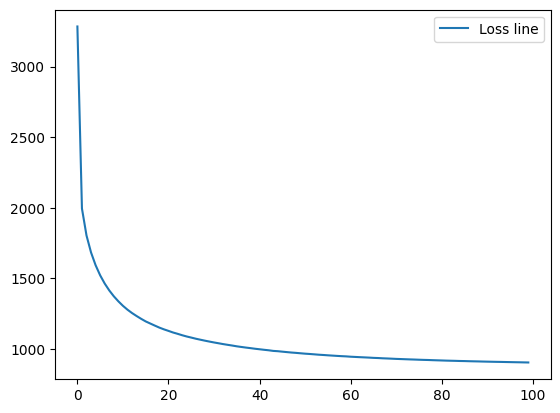

In [17]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.plot([i for i in range(len(losses))], losses, label='Loss line')
# plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

## Bài tập

*   Tiến hành huấn luyện mô hình với số lượng epoch lần lượt là 50, 100, 150.Rút ra nhận xét.





*   Hiển thị một số kết quả



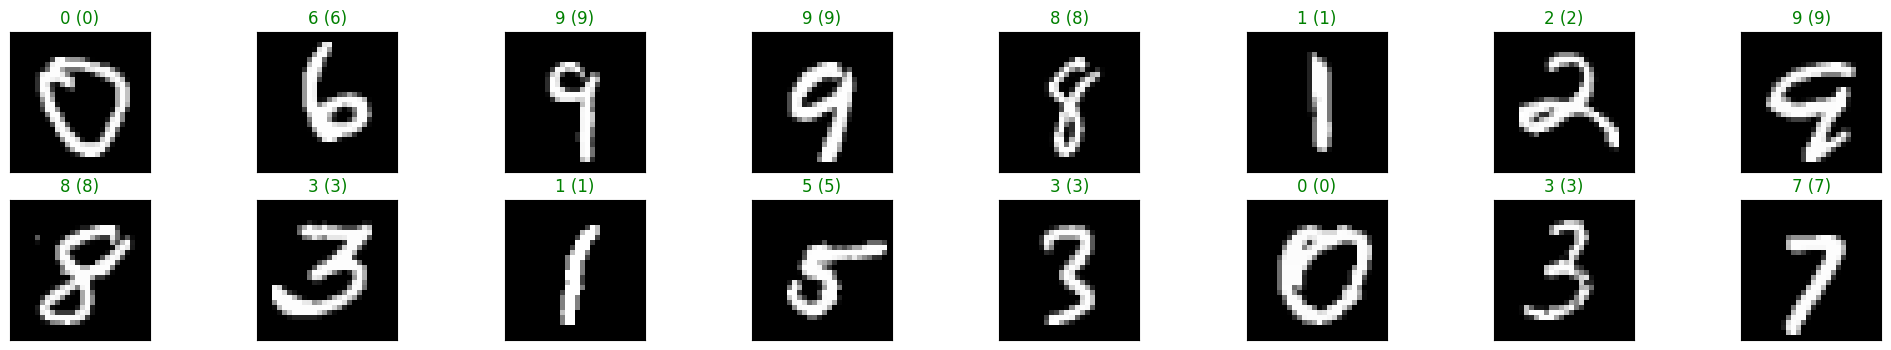

In [17]:
# obtain one batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
# prep images for display
images = images.numpy()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, int(batch_size/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title("{} ({})".format(str(preds[idx].item()), str(labels[idx].item())),
                 color=("green" if preds[idx]==labels[idx] else "red"))

### Epoch = 50

In [18]:
losses50 = []
for epoch in range(50):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    losses50.append(running_loss)
    if epoch % 10 == 9:
        print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

print('Finished Training')

Iteration: 10, accuracy: 0.979
Iteration: 20, accuracy: 0.979
Iteration: 30, accuracy: 0.979
Iteration: 40, accuracy: 0.979
Iteration: 50, accuracy: 0.979
Finished Training


### Epoch = 150

In [19]:
losses150 = []
for epoch in range(150):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    losses150.append(running_loss)
    if epoch % 10 == 9:
        print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

print('Finished Training')

Iteration: 10, accuracy: 0.979
Iteration: 20, accuracy: 0.979
Iteration: 30, accuracy: 0.979
Iteration: 40, accuracy: 0.979
Iteration: 50, accuracy: 0.979
Iteration: 60, accuracy: 0.979
Iteration: 70, accuracy: 0.979
Iteration: 80, accuracy: 0.979
Iteration: 90, accuracy: 0.978
Iteration: 100, accuracy: 0.978
Iteration: 110, accuracy: 0.978
Iteration: 120, accuracy: 0.978
Iteration: 130, accuracy: 0.978
Iteration: 140, accuracy: 0.978
Iteration: 150, accuracy: 0.978
Finished Training


## Bài tập

*   Thiết lập thêm 3 mạng nơ ron với số tầng ẩn lần lượt là 3,5 (số lượng nơ ron của các tầng tùy ý). Với mỗi mạng mới được sinh ra, áp dụng learning-rate lần lượt bằng 0.1, 0,05, 0.001 để huấn luyện. Huấn luyện qua khoảng 100 epoch.
*   Chia tập train hiện có thành 2 phần. **85%** dữ liệu làm tập **train**, **15%** còn lại làm tập **dev**. Huấn luyện các mô hình tạo ra ở bước trên với tập **train** mới, sau đó kiểm thử trên tập **dev**.
* Dùng các model kiểm thử trên tập **test**. So sánh model cho kết quả tốt nhất khi kiểm thử trên 2 tập này và rút ra nhận xét về vai trò của tập **dev**



In [65]:
# Split the training data into train and dev
from torch.utils.data import random_split, DataLoader, TensorDataset

Dataset = TensorDataset(x_train, y_train)
train_size = int(0.85*len(Dataset))
dev_size = len(Dataset) - train_size
train_dataset, dev_dataset = random_split(Dataset, [train_size, dev_size])

In [67]:
train_dataset = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_dataset = DataLoader(dev_dataset, batch_size=batch_size, shuffle=True)

In [89]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).

# Network parameters.
n_hidden_1 = 512 # 1st layer number of neurons.
n_hidden_2 = 256 # 2nd layer number of neurons.
n_hidden_3 = 128 # 3rd layer number of neurons.
n_hidden_4 = 64 # 4th layer number of neurons.
n_hidden_5 = 32 # 5th layer number of neurons.

In [90]:
# criterion
criterion = nn.CrossEntropyLoss()
# optimizer with lr = 0.1, 0.05, 0.001 respectively
optimizer0_1 = optim.SGD(model.parameters(), lr=0.1)
optimizer0_05 = optim.SGD(model.parameters(), lr=0.05)
optimizer0_001 = optim.SGD(model.parameters(), lr=0.001)

In [91]:
# Build neural network with 3 hidden layers

class MLPModel3(nn.Module):
  def __init__(self):
    super(MLPModel3, self).__init__()
    self.fc1 = nn.Linear(num_features, n_hidden_1)
    self.fc2 = nn.Linear(n_hidden_1, n_hidden_2)
    self.fc3 = nn.Linear(n_hidden_2, n_hidden_3)
    self.fc4 = nn.Linear(n_hidden_3, num_classes)

  def forward(self, x):
    x = x.view(-1, 28*28)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.fc4(x)
    return x

model3 = MLPModel3()
print(model3)

MLPModel3(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [94]:
# Build neural network with 5 hidden layers

class MLPModel5(nn.Module):
  def __init__(self):
    super(MLPModel5, self).__init__()
    self.fc1 = nn.Linear(num_features, n_hidden_1)
    self.fc2 = nn.Linear(n_hidden_1, n_hidden_2)
    self.fc3 = nn.Linear(n_hidden_2, n_hidden_3)
    self.fc4 = nn.Linear(n_hidden_3, n_hidden_4)
    self.fc5 = nn.Linear(n_hidden_4, n_hidden_5)
    self.fc6 = nn.Linear(n_hidden_5, num_classes)

  def forward(self, x):
    x = x.view(-1, 28*28)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = F.relu(self.fc5(x))
    x = self.fc6(x)
    return x

model5 = MLPModel5()
print(model5)

MLPModel5(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (fc5): Linear(in_features=64, out_features=32, bias=True)
  (fc6): Linear(in_features=32, out_features=10, bias=True)
)


In [99]:
# accuracy for dev and test set
def accuracy_dev(estimator):
  correct = 0
  total = 0
  with torch.no_grad():
    for data in dev_dataset:
      images, labels = data
      outputs = estimator(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  return correct/total

def accuracy_test(estimator):
  correct = 0
  total = 0
  with torch.no_grad():
    for data in dev_dataset:
      images, labels = data
      outputs = estimator(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  return correct/total

### 3 hidden layers

In [100]:
losses0_1 = []
print('Learning rate = 0.1')
for epoch in range(100):
  running_loss = 0.0
  for i, data in enumerate(train_dataset, 0):
    inputs, labels = data
    optimizer0_1.zero_grad()

    outputs = model3(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer0_1.step()

    running_loss += loss.item()
  losses0_1.append(running_loss)
  if epoch % 10 == 9:
    print('Iteration: %d, accuracy on dev and test: %.3f, %.3f' %(epoch +1, accuracy_dev(model3), accuracy_test(model3)))

print('Finished Training')

Learning rate = 0.1
Iteration: 10, accuracy on dev and test: 0.114, 0.114
Iteration: 20, accuracy on dev and test: 0.114, 0.114
Iteration: 30, accuracy on dev and test: 0.114, 0.114
Iteration: 40, accuracy on dev and test: 0.114, 0.114
Iteration: 50, accuracy on dev and test: 0.114, 0.114
Iteration: 60, accuracy on dev and test: 0.114, 0.114
Iteration: 70, accuracy on dev and test: 0.114, 0.114
Iteration: 80, accuracy on dev and test: 0.114, 0.114
Iteration: 90, accuracy on dev and test: 0.114, 0.114
Iteration: 100, accuracy on dev and test: 0.114, 0.114
Finished Training


In [101]:
losses0_05 = []
print('Learning rate = 0.05')
for epoch in range(100):
  running_loss = 0.0
  for inputs, labels in train_dataset:
    optimizer0_05.zero_grad()

    outputs = model3(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer0_05.step()

    running_loss += loss.item()
  losses0_05.append(running_loss)
  if epoch % 10 == 9:
    print('Iteration: %d, accuracy on dev and test: %.3f, %.3f' %(epoch +1, accuracy_dev(model3), accuracy_test(model3)))

print('Finished Training')

Learning rate = 0.05
Iteration: 10, accuracy on dev and test: 0.114, 0.114
Iteration: 20, accuracy on dev and test: 0.114, 0.114
Iteration: 30, accuracy on dev and test: 0.114, 0.114
Iteration: 40, accuracy on dev and test: 0.114, 0.114
Iteration: 50, accuracy on dev and test: 0.114, 0.114
Iteration: 60, accuracy on dev and test: 0.114, 0.114
Iteration: 70, accuracy on dev and test: 0.114, 0.114
Iteration: 80, accuracy on dev and test: 0.114, 0.114
Iteration: 90, accuracy on dev and test: 0.114, 0.114
Iteration: 100, accuracy on dev and test: 0.114, 0.114
Finished Training


In [103]:
losses0_001 = []
print('Learning rate = 0.001')
for epoch in range(100):
  running_loss = 0.0
  for inputs, labels in train_dataset:
    optimizer0_001.zero_grad()

    outputs = model3(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer0_001.step()

    running_loss += loss.item()
  losses0_001.append(running_loss)
  if epoch % 10 == 9:
    print('Iteration: %d, accuracy on dev and test: %.3f, %.3f' %(epoch +1, accuracy_dev(model3), accuracy_test(model3)))

print('Finished Training')

Learning rate = 0.001
Iteration: 10, accuracy on dev and test: 0.114, 0.114
Iteration: 20, accuracy on dev and test: 0.114, 0.114
Iteration: 30, accuracy on dev and test: 0.114, 0.114
Iteration: 40, accuracy on dev and test: 0.114, 0.114
Iteration: 50, accuracy on dev and test: 0.114, 0.114
Iteration: 60, accuracy on dev and test: 0.114, 0.114
Iteration: 70, accuracy on dev and test: 0.114, 0.114
Iteration: 80, accuracy on dev and test: 0.114, 0.114
Iteration: 90, accuracy on dev and test: 0.114, 0.114
Iteration: 100, accuracy on dev and test: 0.114, 0.114
Finished Training


### 5 hidden layers

In [104]:
losses0_1 = []
print('Learning rate = 0.1')
for epoch in range(100):
  running_loss = 0.0
  for i, data in enumerate(train_dataset, 0):
    inputs, labels = data
    optimizer0_1.zero_grad()

    outputs = model5(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer0_1.step()

    running_loss += loss.item()
  losses0_1.append(running_loss)
  if epoch % 10 == 9:
    print('Iteration: %d, accuracy on dev and test: %.3f, %.3f' %(epoch +1, accuracy_dev(model5), accuracy_test(model5)))

print('Finished Training')

Learning rate = 0.1
Iteration: 10, accuracy on dev and test: 0.090, 0.090
Iteration: 20, accuracy on dev and test: 0.090, 0.090
Iteration: 30, accuracy on dev and test: 0.090, 0.090
Iteration: 40, accuracy on dev and test: 0.090, 0.090
Iteration: 50, accuracy on dev and test: 0.090, 0.090
Iteration: 60, accuracy on dev and test: 0.090, 0.090
Iteration: 70, accuracy on dev and test: 0.090, 0.090
Iteration: 80, accuracy on dev and test: 0.090, 0.090
Iteration: 90, accuracy on dev and test: 0.090, 0.090
Iteration: 100, accuracy on dev and test: 0.090, 0.090
Finished Training


In [ ]:
losses0_05 = []
print('Learning rate = 0.05')
for epoch in range(100):
  running_loss = 0.0
  for inputs, labels in train_dataset:
    optimizer0_05.zero_grad()

    outputs = model5(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer0_05.step()

    running_loss += loss.item()
  losses0_05.append(running_loss)
  if epoch % 10 == 9:
    print('Iteration: %d, accuracy on dev and test: %.3f, %.3f' %(epoch +1, accuracy_dev(model5), accuracy_test(model5)))

print('Finished Training')

In [ ]:
losses0_001 = []
print('Learning rate = 0.001')
for epoch in range(100):
  running_loss = 0.0
  for inputs, labels in train_dataset:
    optimizer0_001.zero_grad()

    outputs = model5(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer0_001.step()

    running_loss += loss.item()
  losses0_001.append(running_loss)
  if epoch % 10 == 9:
    print('Iteration: %d, accuracy on dev and test: %.3f, %.3f' %(epoch +1, accuracy_dev(model5), accuracy_test(model5)))

print('Finished Training')

#### Đối với bài toán này, số tầng ẩn càng cao mô hình càng thiếu chính xác